In [38]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [39]:
df = pd.read_csv("C:/Users/simaran/Downloads/netflix.csv")

In [40]:
df

,Titles,Year,Rating,IMDB_Rating,Netflix
0,Breaking Bad,2008,18+,9.5,1
1,Game of Thrones,2011,18+,9.3,0
2,Rick and Morty,2013,18+,9.2,0
3,Dark,2017,16+,8.8,1
4,Stranger Things,2016,16+,8.8,1
5,Avatar: The Last Airbender,2005,7+,9.2,1
6,Sherlock,2010,16+,9.1,1
7,Chernobyl,2019,18+,9.4,0
8,Friends,1994,16+,8.9,0
9,The Office,2005,16+,8.9,1


In [41]:
df.head()

,Titles,Year,Rating,IMDB_Rating,Netflix
0,Breaking Bad,2008,18+,9.5,1
1,Game of Thrones,2011,18+,9.3,0
2,Rick and Morty,2013,18+,9.2,0
3,Dark,2017,16+,8.8,1
4,Stranger Things,2016,16+,8.8,1


In [42]:
print("Shape:",df.shape)

Shape: (50, 5)


In [43]:
print("Columns:",df.columns)

Columns: Index(['Titles', 'Year', 'Rating', 'IMDB_Rating', 'Netflix'], dtype='object')


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Titles       50 non-null     object 
 1   Year         50 non-null     int64  
 2   Rating       50 non-null     object 
 3   IMDB_Rating  50 non-null     float64
 4   Netflix      50 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 2.1+ KB


In [45]:
df = df.drop_duplicates()

In [46]:
print(df.isnull().sum())

Titles         0
Year           0
Rating         0
IMDB_Rating    0
Netflix        0
dtype: int64


In [47]:
df['IMDB_Rating'].mean()

np.float64(8.722000000000001)

# Netflix vs Non-Netflix

In [48]:
netflix = df[df['Netflix'] == 1]
non_netflix = df[df['Netflix'] == 0]

print("Netflix Shows:", len(netflix))
print("Non-Netflix Shows:", len(non_netflix))

Netflix Shows: 19
Non-Netflix Shows: 31


# Rating Comparison

In [49]:
print("Netflix Avg:", netflix['IMDB_Rating'].mean())
print("Non-Netflix Avg:", non_netflix['IMDB_Rating'].mean())

Netflix Avg: 8.657894736842104
Non-Netflix Avg: 8.761290322580646


# Year-wise Trend 

In [50]:
df.groupby('Year')['IMDB_Rating'].mean()

Year
1989    8.700000
1994    8.900000
1997    8.700000
1999    9.200000
2001    9.400000
2002    9.150000
2004    8.500000
2005    8.825000
2006    8.600000
2007    8.350000
2008    8.950000
2009    8.650000
2010    8.650000
2011    8.866667
2013    8.700000
2014    8.950000
2015    8.650000
2016    8.566667
2017    8.550000
2019    8.575000
Name: IMDB_Rating, dtype: float64

# Top Shows

In [51]:
df.sort_values(by='IMDB_Rating', ascending=False).head(5)

,Titles,Year,Rating,IMDB_Rating,Netflix
0,Breaking Bad,2008,18+,9.5,1
7,Chernobyl,2019,18+,9.4,0
15,Band of Brothers,2001,18+,9.4,0
1,Game of Thrones,2011,18+,9.3,0
11,The Wire,2002,18+,9.3,0


# IMBD Rating Distribution

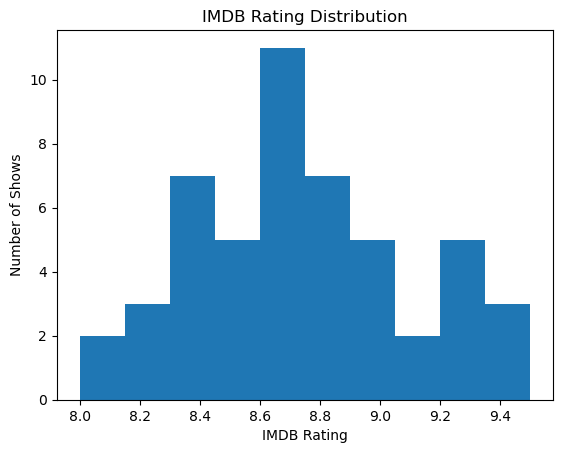

In [52]:
plt.hist(df['IMDB_Rating'])
plt.title("IMDB Rating Distribution")   
plt.xlabel("IMDB Rating")               
plt.ylabel("Number of Shows")  
plt.show()

# Year-wise Trend 

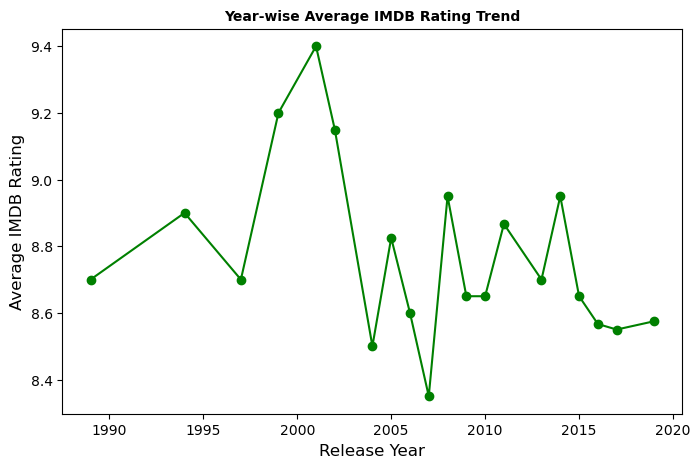

In [53]:
yearly = df.groupby('Year')['IMDB_Rating'].mean()
plt.figure(figsize=(8,5))
plt.plot(yearly, marker='o', linestyle='-',color='green')
plt.title("Year-wise Average IMDB Rating Trend", fontsize=10, fontweight='bold')
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Average IMDB Rating", fontsize=12)
plt.show()

# Content Rating

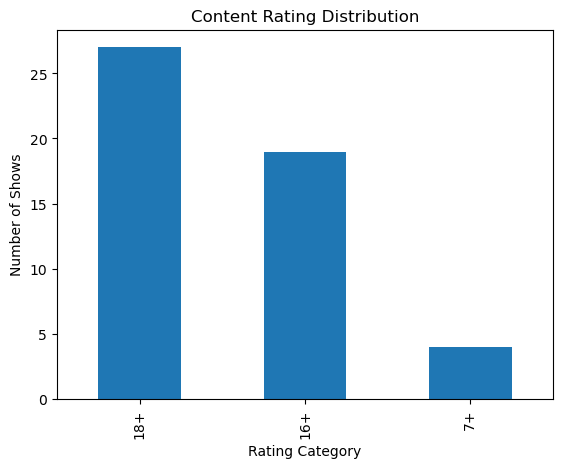

In [54]:
df['Rating'].value_counts().plot(kind='bar')
plt.title("Content Rating Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Shows") 
plt.show()

# IMDB Rating Distribution of Netflix Shows 

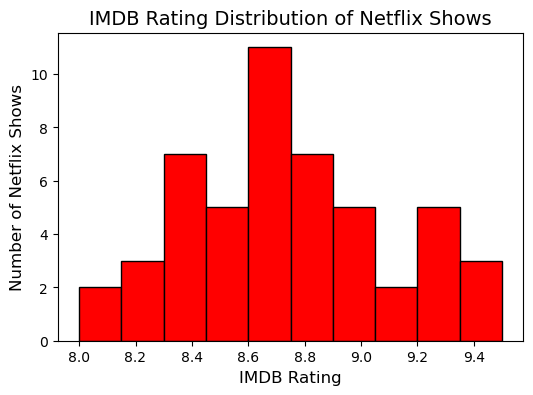

In [55]:
plt.figure(figsize=(6,4))
plt.hist(df['IMDB_Rating'],bins=10, color='red', edgecolor='black')
plt.title("IMDB Rating Distribution of Netflix Shows",fontsize=14,fontweight='light')
plt.xlabel("IMDB Rating",fontsize=12)
plt.ylabel("Number of Netflix Shows",fontsize=12)
plt.show()

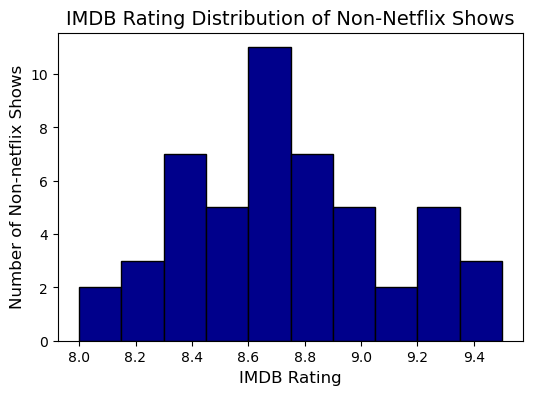

In [56]:
plt.figure(figsize=(6,4))
plt.hist(df['IMDB_Rating'],bins=10, color='darkblue', edgecolor='black')
plt.title("IMDB Rating Distribution of Non-Netflix Shows",fontsize=14,fontweight='light')
plt.xlabel("IMDB Rating",fontsize=12)
plt.ylabel("Number of Non-netflix Shows",fontsize=12)
plt.show()

In [57]:
print("Columns:",df.columns)

Columns: Index(['Titles', 'Year', 'Rating', 'IMDB_Rating', 'Netflix'], dtype='object')


In [58]:
print(df['Netflix'].value_counts())

Netflix
0    31
1    19
Name: count, dtype: int64


In [59]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [60]:
netflix_counts = df['Netflix'].value_counts()

print("Netflix Content:", netflix_counts[1])
print("Non-Netflix Content:", netflix_counts[0])

Netflix Content: 19
Non-Netflix Content: 31


In [61]:
netflix = df[df['Netflix'] == 1]['Rating'].value_counts()
non_netflix = df[df['Netflix'] == 0]['Rating'].value_counts()

print("Netflix")
print(netflix)

print("\nNon-Netflix")
print(non_netflix)

Netflix
Rating
18+    12
16+     6
7+      1
Name: count, dtype: int64

Non-Netflix
Rating
18+    15
16+    13
7+      3
Name: count, dtype: int64


In [62]:
comparison = pd.crosstab(df['Rating'], df['Netflix'])

In [63]:
comparison.columns = ['Non-Netflix', 'Netflix']

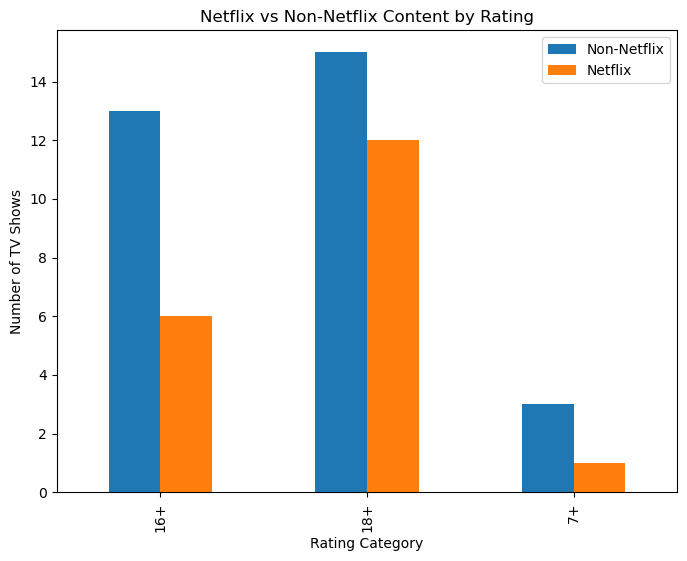

In [64]:
comparison.plot(kind='bar', figsize=(8,6))
plt.title('Netflix vs Non-Netflix Content by Rating')
plt.xlabel('Rating Category')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=90)  
plt.legend(title='')

plt.show()

In [65]:
rating_percentage = (df['Rating'].value_counts(normalize=True) * 100).round(2)
print(rating_percentage)

Rating
18+    54.0
16+    38.0
7+      8.0
Name: proportion, dtype: float64


# Netflix and Non-Netflix percentage by Rating

In [66]:
comparison = pd.crosstab(df['Rating'], df['Netflix'])

# Convert counts to percentage of total dataset
percentage = (comparison / len(df) * 100).round(2)

percentage.columns = ['Non-Netflix %', 'Netflix %']

print(percentage)

        Non-Netflix %  Netflix %
Rating                          
16+              26.0       12.0
18+              30.0       24.0
7+                6.0        2.0


In [67]:
netflix_percent = (df[df['Netflix']==1]['Rating'].value_counts(normalize=True)*100).round(2)
print(netflix_percent)

Rating
18+    63.16
16+    31.58
7+      5.26
Name: proportion, dtype: float64


In [68]:
non_netflix_percent = (df[df['Netflix']==0]['Rating'].value_counts(normalize=True)*100).round(2)
print(non_netflix_percent)

Rating
18+    48.39
16+    41.94
7+      9.68
Name: proportion, dtype: float64


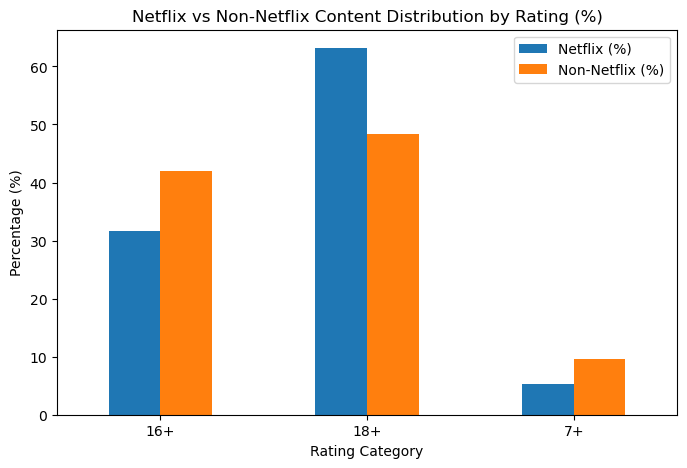

In [69]:
# Create dataframe for plotting

percent_df = pd.DataFrame({'Netflix (%)': netflix_percent,'Non-Netflix (%)': non_netflix_percent}).fillna(0)

# Order ratings
percent_df = percent_df.reindex(['16+', '18+', '7+'])

# Plot
percent_df.plot(kind='bar', figsize=(8,5))
plt.title('Netflix vs Non-Netflix Content Distribution by Rating (%)')
plt.xlabel('Rating Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend()

plt.show()

In [70]:
platform_percent = (df['Netflix'].value_counts(normalize=True) * 100).round(2)

print("Netflix Content Percentage =", platform_percent[1], "%")
print("Non-Netflix Content Percentage =", platform_percent[0], "%")

Netflix Content Percentage = 38.0 %
Non-Netflix Content Percentage = 62.0 %


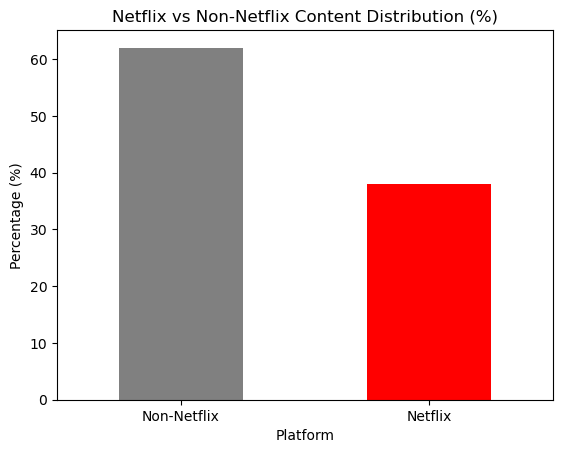

In [78]:
platform_percent.index = ['Non-Netflix', 'Netflix']
platform_percent.plot(kind='bar',color=['gray', 'red'])

plt.title('Netflix vs Non-Netflix Content Distribution (%)')
plt.xlabel('Platform')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

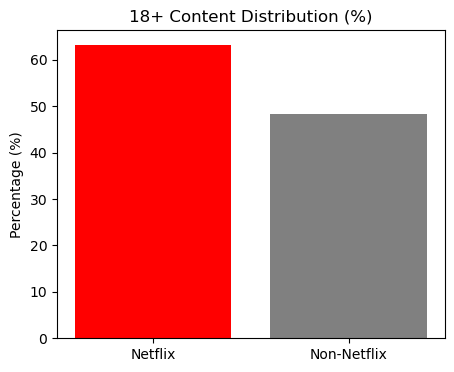

In [80]:
data = [63.16, 48.39]
labels = ['Netflix', 'Non-Netflix']

plt.figure(figsize=(5,4))
plt.bar(labels, data, color=['red', 'gray']) 

plt.title('18+ Content Distribution (%)')
plt.ylabel('Percentage (%)')

plt.show()

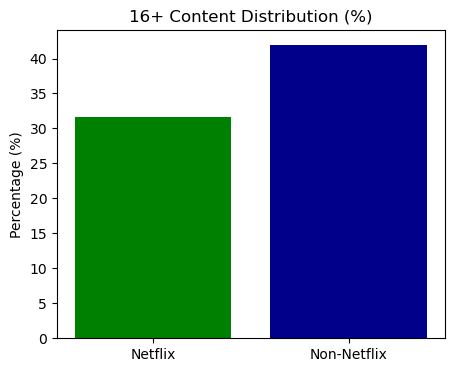

In [82]:
data = [31.58, 41.94]
labels= ['Netflix', 'Non-Netflix']

plt.figure(figsize=(5,4))
plt.bar(labels,data,color=['green','darkblue'])

plt.title('16+ Content Distribution (%)')
plt.ylabel('Percentage (%)')

plt.show()

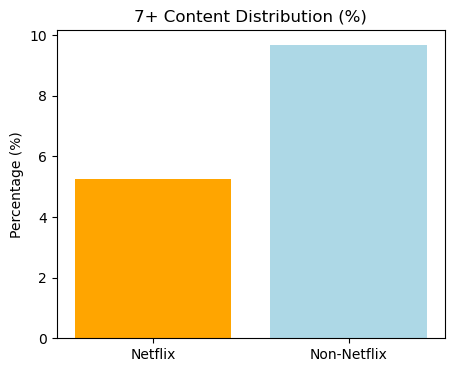

In [85]:
data = [5.26, 9.68]
labels= ['Netflix', 'Non-Netflix']

plt.figure(figsize=(5,4))
plt.bar(labels,data,color=['orange','lightblue'])

plt.title('7+ Content Distribution (%)')
plt.ylabel('Percentage (%)')

plt.show()